# Tutorial 2: Integration of spatial transcriptome-proteome human lymph node dataset.

This notebook provides a step-by-step guide on how to obtain joint embeddings on the human lymph node dataset.

In [ ]:
# Import required libraries and dependencies
import torch
import warnings
import scanpy as sc
import matplotlib.pyplot as plt

from maple.model import *
from maple.utils import *
from maple.preprocess import *
from sklearn.metrics import (homogeneity_score, completeness_score, mutual_info_score, normalized_mutual_info_score,
                             adjusted_mutual_info_score, fowlkes_mallows_score, adjusted_rand_score)

# Initialize global settings
seed = 11452
fix_seed(seed)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
warnings.filterwarnings('ignore', category=UserWarning)

Global random seed set to: 11452.


In [2]:
# Load the human lymph node dataset and transcriptome-proteome mapping table
adata_rna = sc.read_h5ad('../data/human_lymph_node/adata_rna.h5ad')
adata_pro = sc.read_h5ad('../data/human_lymph_node/adata_pro.h5ad')
mapping_df = pd.read_csv('../data/feature_prior/pro2gene.csv')

# Retrieve genes corresponding to proteins for feature alignment
custom_mapping = {}
for _, row in mapping_df.iterrows():
    pro_name = str(row['protein name']).strip()
    rna_names = str(row['gene name']).replace('/', ',').split(',') 
    custom_mapping[pro_name] = [g.strip() for g in rna_names if g.strip() and g.strip() != 'nan']
    
target_rna = []
all_pro_symbols = adata_pro.var['gene_symbol'].astype(str).tolist()
for pro_name in all_pro_symbols:
    target_genes = custom_mapping.get(pro_name, [pro_name])
    target_rna.extend(target_genes)
target_rna = list(set(target_rna))

# Preprocess the RNA data, retain genes corresponding to proteins for feature alignment
adata_rna.layers['counts'] = adata_rna.X.copy()
sc.pp.highly_variable_genes(adata_rna, flavor='seurat_v3', n_top_genes=3000)
valid_to_protect = [g for g in target_rna if g in adata_rna.var_names]
adata_rna.var.loc[valid_to_protect, 'highly_variable'] = True
sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)
sc.pp.scale(adata_rna)
adata_rna.obsm['X_feat'] = compute_pca(adata_rna[:, adata_rna.var['highly_variable']].X, 40)

# Preprocess the protein data
adata_pro.layers['counts'] = adata_pro.X.copy()
clr_normalize_each_cell(adata_pro)
sc.pp.scale(adata_pro)
adata_pro.obsm['X_feat'] = compute_pca(adata_pro.X, adata_pro.n_vars-1)

# Inspect the processed data
adata_rna, adata_pro

(AnnData object with n_obs × n_vars = 3484 × 18085
     obs: 'annotation'
     var: 'gene_ids', 'feature_types', 'genome', 'gene_symbol', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
     uns: 'hvg', 'log1p'
     obsm: 'spatial', 'X_feat'
     layers: 'counts',
 AnnData object with n_obs × n_vars = 3484 × 31
     obs: 'annotation'
     var: 'gene_ids', 'feature_types', 'gene_symbol', 'mean', 'std'
     obsm: 'spatial', 'X_feat'
     layers: 'counts')

In [3]:
# Create a MAPLE model and initialize it
maple = MAPLE(
        adata_rna=adata_rna,
        adata_pro=adata_pro,
        device=device
    )

# Train the MAPLE model
maple.train_modal()

The spatial, feature, and joint graphs have been successfully generated.
Loaded pre-computed real gene ontology graph from '../data/feature_prior/go_graphs/go_graph_20260522_144945.npz'.
The spatial, feature, and joint graphs have been successfully generated.
The real cross-modal translational graph has been successfully generated.


Training:  81%|████████  | 1613/2000 [00:24<00:05, 65.14it/s, recon_loss_rna=0.941075, recon_loss_pro=0.394743, trans_loss=0.196091, total_loss=1.355427]

Early stopping triggered at epoch 1614.
Total training time: 24.76 seconds.
Peak GPU memory usage: 325.06 MB.


In [4]:
# Prepare a new AnnData for unified qualitative and quantitative analysis
adata = adata_rna.copy()

# Extract the joint embeddings
with torch.no_grad():
    maple.eval()
    results = maple.forward()
    adata.obsm['maple_emb'] = results['joint_emb'].cpu().numpy()

# Perform Leiden clustering on the joint embeddings
optimize_leiden(adata=adata, n_clusters=6, used_obsm='maple_emb',
                add_obs='maple_leiden', res_min=0.1, res_max=1.0)

Current resolution is 0.5500, found 6 clusters.
Success: Leiden found 6 clusters at resolution 0.5500 (Attempt 1).


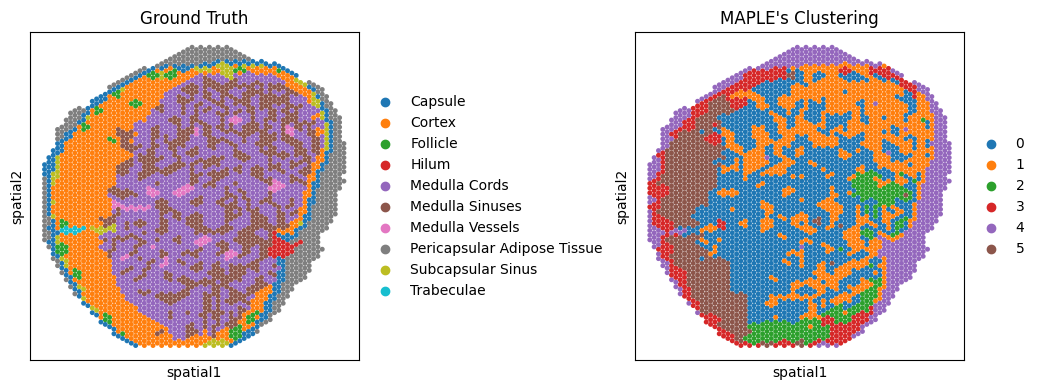

In [5]:
# Visualize spatial ground truth and MAPLE's clustering
fig, ax_list = plt.subplots(1, 2, figsize=(10.5, 4))

sc.pl.embedding(adata, basis='spatial', title='Ground Truth', color='annotation', ax=ax_list[0], s=50, show=False)
sc.pl.embedding(adata, basis='spatial', title='MAPLE\'s Clustering', color='maple_leiden', ax=ax_list[1], s=50, show=False)

plt.tight_layout(w_pad=0.5)
plt.show()

In [ ]:
# Calculate supervised metrics for spatial domain segmentation
GT_labels = adata.obs['annotation']
cluster_labels = adata.obs['maple_leiden']

Homo = homogeneity_score(GT_labels, cluster_labels)
Comp = completeness_score(GT_labels, cluster_labels)
MI = mutual_info_score(GT_labels, cluster_labels)
NMI = normalized_mutual_info_score(GT_labels, cluster_labels)
AMI = adjusted_mutual_info_score(GT_labels, cluster_labels)
FMI = fowlkes_mallows_score(GT_labels, cluster_labels)
ARI = adjusted_rand_score(GT_labels, cluster_labels)

print(f'Homo: {Homo:.4f}, Comp: {Comp:.4f}, MI: {MI:.4f}, NMI: {NMI:.4f}, AMI: {AMI:.4f}, FMI: {FMI:.4f}, ARI: {ARI:.4f}.')

Homo: 0.4315, Comp: 0.4536, MI: 0.7279, NMI: 0.4423, AMI: 0.4400, FMI: 0.5227, ARI: 0.3798.
